# Label Distribution Landscape

This notebook visualizes the relationship between event log properties (number of unique activities, average trace length) and the ground truth label distribution across all datasets.

**Visualization**: Each dataset is represented by:
- Position based on log properties (activities × trace length)
- Pie chart showing the distribution of best alignment heuristics

In [36]:
import sys
import os
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import ConnectionPatch
from collections import Counter
from tqdm import tqdm
from adjustText import adjust_text

# Add project root to path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

from features import CompositeFeatureExtractor
from models.evaluator import HEURISTIC_ALIASES, get_heuristic_alias

## Configuration

In [37]:
# Paths
PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data"
RUNS_DIR = PROJECT_ROOT / "cache" /".runs"

# Color scheme for heuristics (consistent across all plots)
HEURISTIC_COLORS = {
    'Dijkstra': '#e41a1c',
    'A*-ILP': '#377eb8',
    'A*': '#4daf4a',
    'RequiredModelMove': '#984ea3',
    'RemainingActivities': '#ff7f00',
}

# Feature indices (from CompositeFeatureExtractor)

_fe = CompositeFeatureExtractor()
feature_names = _fe.feature_names

# Find indices for the features we need
FEATURE_IDX_TRANSITIONS = feature_names.index('model_n_transitions')
FEATURE_IDX_TRACE_LENGTH = feature_names.index('trace_length')

print(f"\nData directory: {DATA_DIR.absolute()}")
print(f"Runs directory: {RUNS_DIR.absolute()}")


Data directory: /Users/michael/Daten/Master/Praktikum_Process_Mining/pm_ws25/data
Runs directory: /Users/michael/Daten/Master/Praktikum_Process_Mining/pm_ws25/cache/.runs


## Dataset Mapping

Create mapping from UUID to human-readable dataset name.

In [38]:
def build_dataset_mapping():
    """
    Build mapping from UUID to dataset name by scanning data directory.
    
    Returns:
        dict: {uuid: dataset_name}
    """
    mapping = {}
    
    for uuid_dir in DATA_DIR.iterdir():
        if not uuid_dir.is_dir():
            continue
        
        uuid = uuid_dir.name
        
        # Find the first .xes or .csv file
        for file in uuid_dir.iterdir():
            if file.suffix in ['.xes', '.csv']:
                # Use filename without extension as dataset name
                name = file.stem.replace('%20', ' ')
                mapping[uuid] = name
                break
    
    return mapping

dataset_mapping = build_dataset_mapping()
print(f"Found {len(dataset_mapping)} datasets:")
for uuid, name in sorted(dataset_mapping.items(), key=lambda x: x[1])[:10]:
    print(f"  {uuid[:8]}...: {name}")
print(f"  ... and {len(dataset_mapping) - 10} more" if len(dataset_mapping) > 10 else "")

Found 29 datasets:
  5f3067df...: BPI Challenge 2017
  3301445f...: BPI Challenge 2018
  01345ac4...: BPI2016_Clicks_Logged_In
  9b99a146...: BPI2016_Clicks_NOT_Logged_In
  e30ba0c8...: BPI2016_Complaints
  2b02709f...: BPI2016_Questions
  c3f3ba2d...: BPI2016_Werkmap_Messages
  a0addfda...: BPIC15_1
  63a8435a...: BPIC15_2
  ed445cdd...: BPIC15_3
  ... and 19 more


## Helper Functions

In [39]:
def parse_feature_vector(s):
    """Parse feature vector from NumPy string representation."""
    s_clean = str(s).strip('[]').replace('\n', ' ')
    values = [float(x) for x in s_clean.split() if x]
    return np.array(values)


def load_runs_csv(runs_path):
    """Load runs.csv file."""
    return pd.read_csv(runs_path)


def compute_label_distribution(df):
    """Compute distribution of best heuristics (labels) with counts and percentages."""
    best_indices = df.groupby('combination_id')['time_total_mean'].idxmin()
    labels = df.loc[best_indices]
    
    counter = Counter(labels['aligner'])
    total = sum(counter.values())
    
    counts = {}
    percentages = {}
    for heuristic, count in counter.items():
        alias = get_heuristic_alias(heuristic)
        counts[alias] = count
        percentages[alias] = (count / total) * 100
    
    return {'counts': counts, 'percentages': percentages}


def extract_log_properties_from_features(df):
    """Extract log-level properties by aggregating over feature vectors."""
    df_unique = df.drop_duplicates(subset=['combination_id'])

    transitions_list = []
    trace_lengths_list = []

    for _, row in df_unique.iterrows():
        fv = parse_feature_vector(row['feature_vector'])
        n_transitions = fv[FEATURE_IDX_TRANSITIONS]
        trace_len = fv[FEATURE_IDX_TRACE_LENGTH]

        if (np.isfinite(n_transitions) and np.isfinite(trace_len)
                and n_transitions > 0 and trace_len > 0):
            transitions_list.append(n_transitions)
            trace_lengths_list.append(trace_len)
    
    n_activities = int(np.median(transitions_list))
    avg_trace_len = float(np.median(trace_lengths_list))

    print(f"  Extracted: {len(transitions_list)}/{len(df_unique)} valid vectors "
          f"(activities={n_activities}, trace_len={avg_trace_len:.1f})")

    return {'n_unique_activities': n_activities, 'avg_trace_len': avg_trace_len}

## Load and Process Data

For each dataset:
1. Load runs.csv (contains all aligner results)
2. Extract log properties from feature vectors (median over all combinations)
3. Compute label distribution (which heuristic is best for each combination)

In [40]:
# Process all datasets
results = []

# Process real datasets
print("Processing real datasets...")
for runs_file in tqdm(list(RUNS_DIR.glob("*.runs.csv"))):
    uuid = runs_file.stem.replace('.runs', '')
    
    if uuid == 'synthetic':
        continue
    
    name = dataset_mapping.get(uuid, uuid)
    df = load_runs_csv(runs_file)
    props = extract_log_properties_from_features(df)
    label_dist = compute_label_distribution(df)
    
    results.append({
        'name': name,
        'uuid': uuid,
        'type': 'real',
        'n_unique_activities': props['n_unique_activities'],
        'avg_trace_len': props['avg_trace_len'],
        'label_counts': label_dist['counts'],
        'label_percentages': label_dist['percentages'],
        'n_samples': len(df.groupby('combination_id')),
    })

# Process synthetic dataset
print("\nProcessing synthetic dataset...")
synthetic_runs = RUNS_DIR / "synthetic.runs.csv"
if synthetic_runs.exists():
    df = load_runs_csv(synthetic_runs)
    props = extract_log_properties_from_features(df)
    label_dist = compute_label_distribution(df)

    results.append({
        'name': 'Synthetic',
        'uuid': 'synthetic',
        'type': 'synthetic',
        'n_unique_activities': props['n_unique_activities'],
        'avg_trace_len': props['avg_trace_len'],
        'label_counts': label_dist['counts'],
        'label_percentages': label_dist['percentages'],
        'n_samples': len(df.groupby('combination_id')),
    })
else:
    print(f"Warning: Synthetic runs file not found at {synthetic_runs}")

print(f"\nSuccessfully processed: {len(results)} datasets")

Processing real datasets...


  6%|▌         | 1/18 [00:00<00:05,  3.02it/s]

  Extracted: 8045/8045 valid vectors (activities=52, trace_len=11.0)


 11%|█         | 2/18 [00:00<00:06,  2.44it/s]

  Extracted: 13848/13848 valid vectors (activities=69, trace_len=13.0)


...

 89%|████████▉ | 16/18 [00:08<00:01,  1.57it/s]

  Extracted: 27273/27273 valid vectors (activities=67, trace_len=15.0)
  Extracted: 1615/1615 valid vectors (activities=11, trace_len=16.0)


100%|██████████| 18/18 [00:08<00:00,  2.01it/s]

  Extracted: 6907/6907 valid vectors (activities=37, trace_len=8.0)

Processing synthetic dataset...


  Extracted: 22728/22998 valid vectors (activities=86, trace_len=21.0)

Successfully processed: 18 datasets


## Results Summary

In [41]:
# Display results as table
summary_data = []
for r in results:
    row = {
        'name': r['name'],
        'type': r['type'],
        'n_samples': r['n_samples'],
        'n_activities': r['n_unique_activities'],
        'avg_trace_len': r['avg_trace_len'],
    }
    for heuristic, pct in r['label_percentages'].items():
        row[f'{heuristic}_%'] = f"{pct:.1f}%"
    summary_data.append(row)

summary_df = pd.DataFrame(summary_data)
summary_df = summary_df.sort_values('type', ascending=False)
summary_df

,name,type,n_samples,n_activities,avg_trace_len,A*-ILP_%,Dijkstra_%,RemainingActivities_%,A*_%,RequiredModelMove_%
17,Synthetic,synthetic,22998,86,21.0,63.4%,22.9%,6.5%,7.2%,0.0%
1,InternationalDeclarations,real,13848,69,13.0,8.3%,61.7%,28.7%,1.4%,NaN
16,Road_Traffic_Fine_Management_Process,real,6907,37,8.0,17.0%,58.3%,21.7%,2.9%,NaN
15,BPI_Challenge_2013_incidents,real,1615,11,16.0,42.0%,27.4%,23.6%,7.0%,NaN
14,PermitLog,real,27273,67,15.0,6.0%,61.6%,30.8%,1.5%,NaN
13,BPI Challenge 2017,real,1613,43,45.0,1.5%,63.9%,33.2%,1.4%,NaN
12,Sepsis Cases - Event Log,real,16703,45,13.0,20.1%,49.9%,24.2%,5.8%,NaN
11,BPIC15_3,real,41899,283,41.0,2.0%,78.8%,19.0%,0.2%,0.0%
10,BPI_Challenge_2019,real,48456,72,11.0,18.8%,51.1%,21.0%,9.1%,0.0%
0,Hospital Billing - Event Log,real,8045,52,11.0,13.8%,55.7%,26.3%,4.2%,NaN


## Visualization: Scatter Plot with Pie Charts

Creates a scatter plot where:
- **X-axis**: Number of unique activities (log scale)
- **Y-axis**: Average trace length (log scale)  
- **Pie charts**: Show label distribution for each dataset

In [42]:
def plot_pie_at_position(ax, position, distribution, colors, size=0.15):
    """
    Plot a pie chart at a specific position on the scatter plot.
    
    Args:
        ax: Main axes
        position: (x, y) tuple in data coordinates
        distribution: dict {label: percentage}
        colors: dict {label: color}
        size: Size of pie chart relative to axes
    """
    # Sort by percentage for consistent ordering
    items = sorted(distribution.items(), key=lambda x: x[1], reverse=True)
    labels = [item[0] for item in items]
    sizes = [item[1] for item in items]
    pie_colors = [colors.get(label, '#cccccc') for label in labels]
    
    # Create inset axes for pie chart
    # Convert data coordinates to figure coordinates
    x_data, y_data = position
    
    # Transform to display coordinates
    x_disp, y_disp = ax.transData.transform((x_data, y_data))
    
    # Transform to figure coordinates
    x_fig, y_fig = ax.figure.transFigure.inverted().transform((x_disp, y_disp))
    
    # Create inset axes
    pie_ax = ax.figure.add_axes([x_fig - size/2, y_fig - size/2, size, size])
    
    # Plot pie chart
    pie_ax.pie(
        sizes,
        colors=pie_colors,
        startangle=90,
        counterclock=False,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
    )
    
    return pie_ax

Dataset positions:
  Hospital Billing - Event Log: activities=52, trace_len=11.0
  InternationalDeclarations: activities=69, trace_len=13.0
  PrepaidTravelCost: activities=68, trace_len=10.0
  BPI_Challenge_2012: activities=62, trace_len=37.0
  BPIC15_4: activities=280, trace_len=43.0
  BPI_Challenge_2013_closed_problems: activities=13, trace_len=9.0
  BPI_Challenge_2013_open_problems: activities=13, trace_len=7.0
  BPI Challenge 2018: activities=33, trace_len=54.0
  RequestForPayment: activities=58, trace_len=7.0
  DomesticDeclarations: activities=43, trace_len=8.0
  BPI_Challenge_2019: activities=72, trace_len=11.0
  BPIC15_3: activities=283, trace_len=41.0
  Sepsis Cases - Event Log: activities=45, trace_len=13.0
  BPI Challenge 2017: activities=43, trace_len=45.0
  PermitLog: activities=67, trace_len=15.0
  BPI_Challenge_2013_incidents: activities=11, trace_len=16.0
  Road_Traffic_Fine_Management_Process: activities=37, trace_len=8.0
  Synthetic: activities=86, trace_len=21.0


/var/folders/_k/t1m9btdd1d7_3xlbnvhy3j580000gn/T/ipykernel_67714/3174415562.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


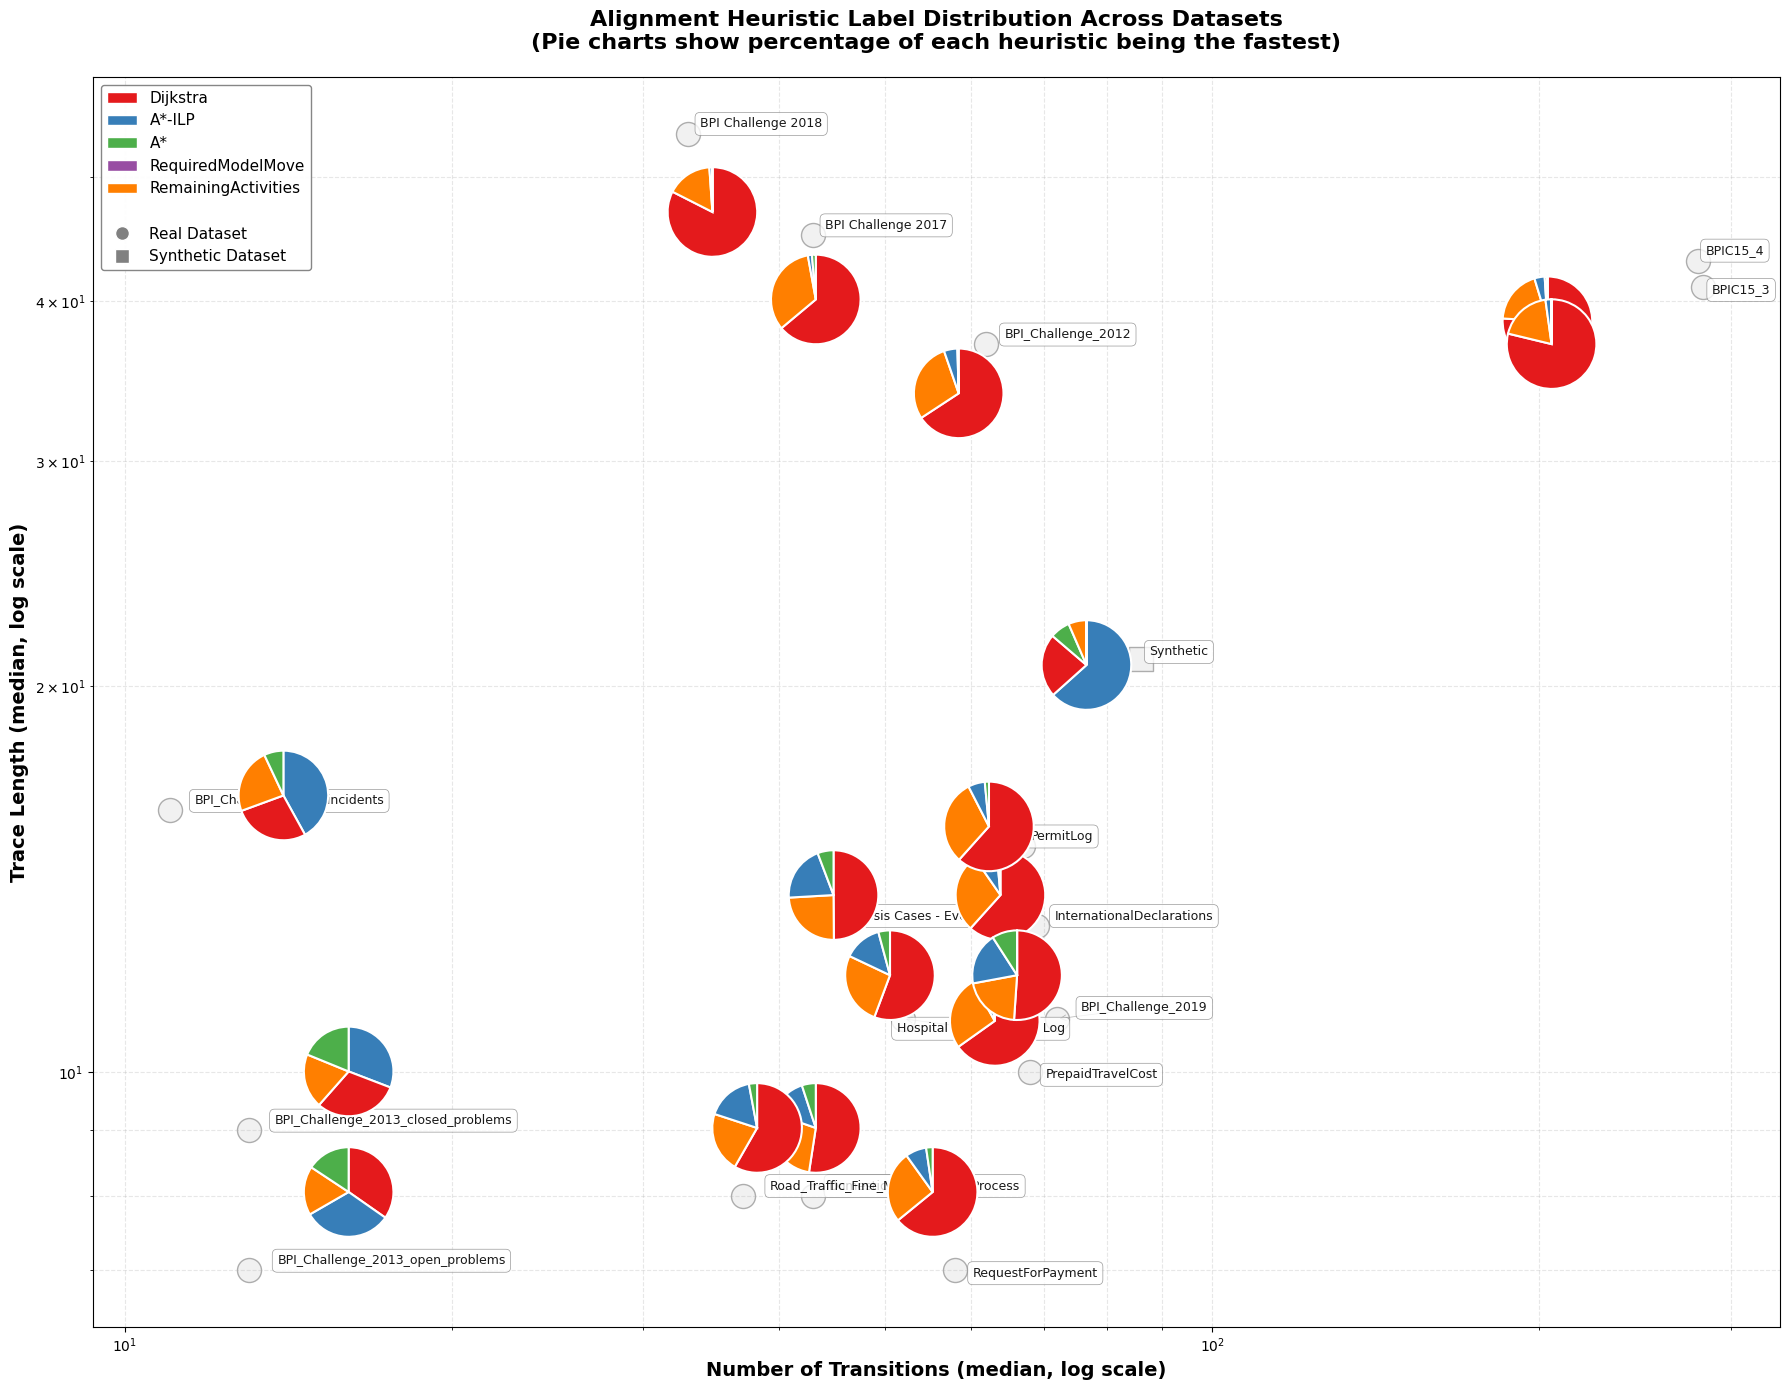


Label Distribution Statistics:

A*:
  Mean: 4.8%
  Median: 2.6%
  Min: 0.0%, Max: 18.8%

A*-ILP:
  Mean: 16.3%
  Median: 11.0%
  Min: 1.1%, Max: 63.4%

Dijkstra:
  Mean: 55.7%
  Median: 60.0%
  Min: 22.9%, Max: 82.5%

RemainingActivities:
  Mean: 23.2%
  Median: 23.9%
  Min: 6.5%, Max: 33.2%

RequiredModelMove:
  Mean: 0.0%
  Median: 0.0%
  Min: 0.0%, Max: 0.0%


In [43]:
# Create main figure
fig, ax = plt.subplots(figsize=(18, 14))

names = [r['name'] for r in results]
n_activities = np.array([r['n_unique_activities'] for r in results])
avg_trace_lengths = np.array([r['avg_trace_len'] for r in results])
types = [r['type'] for r in results]

print("Dataset positions:")
for i, name in enumerate(names):
    print(f"  {name}: activities={n_activities[i]}, trace_len={avg_trace_lengths[i]}")

ax.set_xscale('log')
ax.set_yscale('log')

for i, (x, y, dtype) in enumerate(zip(n_activities, avg_trace_lengths, types)):
    marker = 'o' if dtype == 'real' else 's'
    ax.scatter(x, y, s=300, c='lightgray', marker=marker, alpha=0.3,
               zorder=1, edgecolors='black', linewidths=1)

pie_size = 0.08
for i, result in enumerate(results):
    position = (n_activities[i], avg_trace_lengths[i])
    plot_pie_at_position(ax, position, result['label_percentages'],
                         HEURISTIC_COLORS, size=pie_size)

texts = []
for i, name in enumerate(names):
    text = ax.annotate(
        name, (n_activities[i], avg_trace_lengths[i]), fontsize=9, alpha=0.9,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.8,
                  edgecolor='gray', linewidth=0.5),
        zorder=5)
    texts.append(text)

adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray', lw=0.5, alpha=0.6),
            expand_points=(2.0, 2.0), force_text=(0.5, 0.5), force_points=(0.3, 0.3), ax=ax)

ax.set_xlabel("Number of Transitions (median, log scale)", fontsize=14, fontweight='bold')
ax.set_ylabel("Trace Length (median, log scale)", fontsize=14, fontweight='bold')
ax.set_title("Alignment Heuristic Label Distribution Across Datasets\n"
             "(Pie charts show percentage of each heuristic being the fastest)",
             fontsize=16, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3, linestyle='--', which='both', zorder=0)

legend_elements = [mpatches.Patch(facecolor=color, edgecolor='white', label=heuristic)
                   for heuristic, color in HEURISTIC_COLORS.items()]
legend_elements.extend([
    mpatches.Patch(facecolor='none', edgecolor='none', label=''),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='gray',
               markersize=10, label='Real Dataset'),
    plt.Line2D([0], [0], marker='s', color='w', markerfacecolor='gray',
               markersize=10, label='Synthetic Dataset'),
])
ax.legend(handles=legend_elements, loc='upper left', fontsize=11,
          framealpha=0.95, edgecolor='gray')

plt.tight_layout()
plt.show()

print("\nLabel Distribution Statistics:")
all_heuristics = set()
for r in results:
    all_heuristics.update(r['label_percentages'].keys())

for heuristic in sorted(all_heuristics):
    percentages = [r['label_percentages'].get(heuristic, 0) for r in results]
    print(f"\n{heuristic}:")
    print(f"  Mean: {np.mean(percentages):.1f}%")
    print(f"  Median: {np.median(percentages):.1f}%")
    print(f"  Min: {np.min(percentages):.1f}%, Max: {np.max(percentages):.1f}%")

## Alternative: Stacked Bar Chart

Shows label distribution for each dataset as stacked bars.

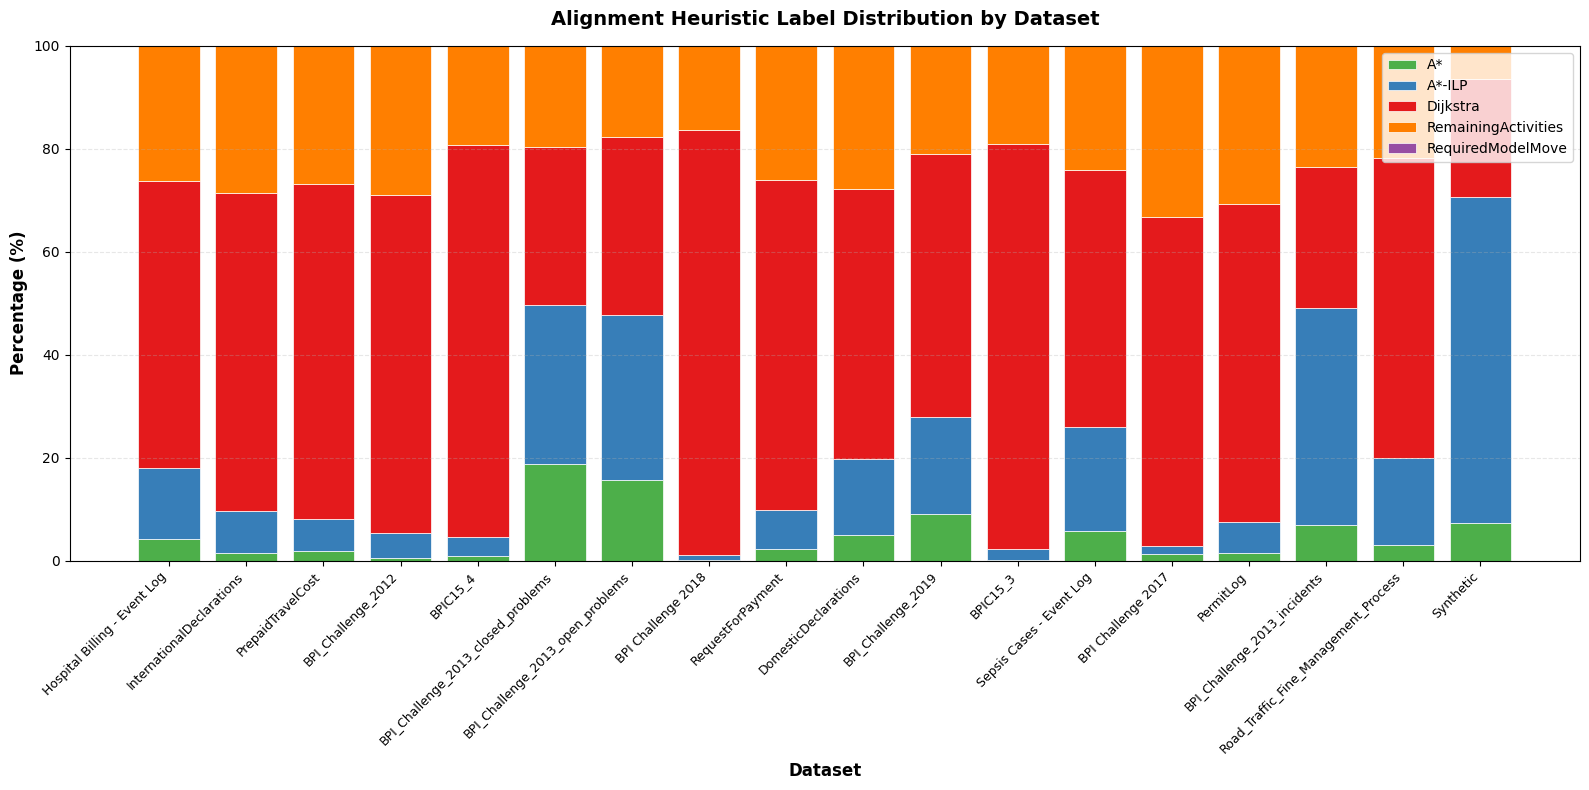

In [44]:
# Create stacked bar chart (percentages)
fig, ax = plt.subplots(figsize=(16, 8))

dataset_names = [r['name'] for r in results]
heuristics = sorted(HEURISTIC_COLORS.keys())

data = {h: [] for h in heuristics}
for result in results:
    for h in heuristics:
        data[h].append(result['label_percentages'].get(h, 0))

x = np.arange(len(dataset_names))
width = 0.8
bottom = np.zeros(len(dataset_names))

for heuristic in heuristics:
    values = data[heuristic]
    ax.bar(x, values, width, bottom=bottom, label=heuristic,
           color=HEURISTIC_COLORS[heuristic], edgecolor='white', linewidth=0.5)
    bottom += values

ax.set_ylabel('Percentage (%)', fontsize=12, fontweight='bold')
ax.set_xlabel('Dataset', fontsize=12, fontweight='bold')
ax.set_title('Alignment Heuristic Label Distribution by Dataset',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(dataset_names, rotation=45, ha='right', fontsize=9)
ax.legend(loc='upper right', fontsize=10)
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

## Absolute Label Counts

Shows the absolute number of samples per heuristic for each dataset as stacked bars.

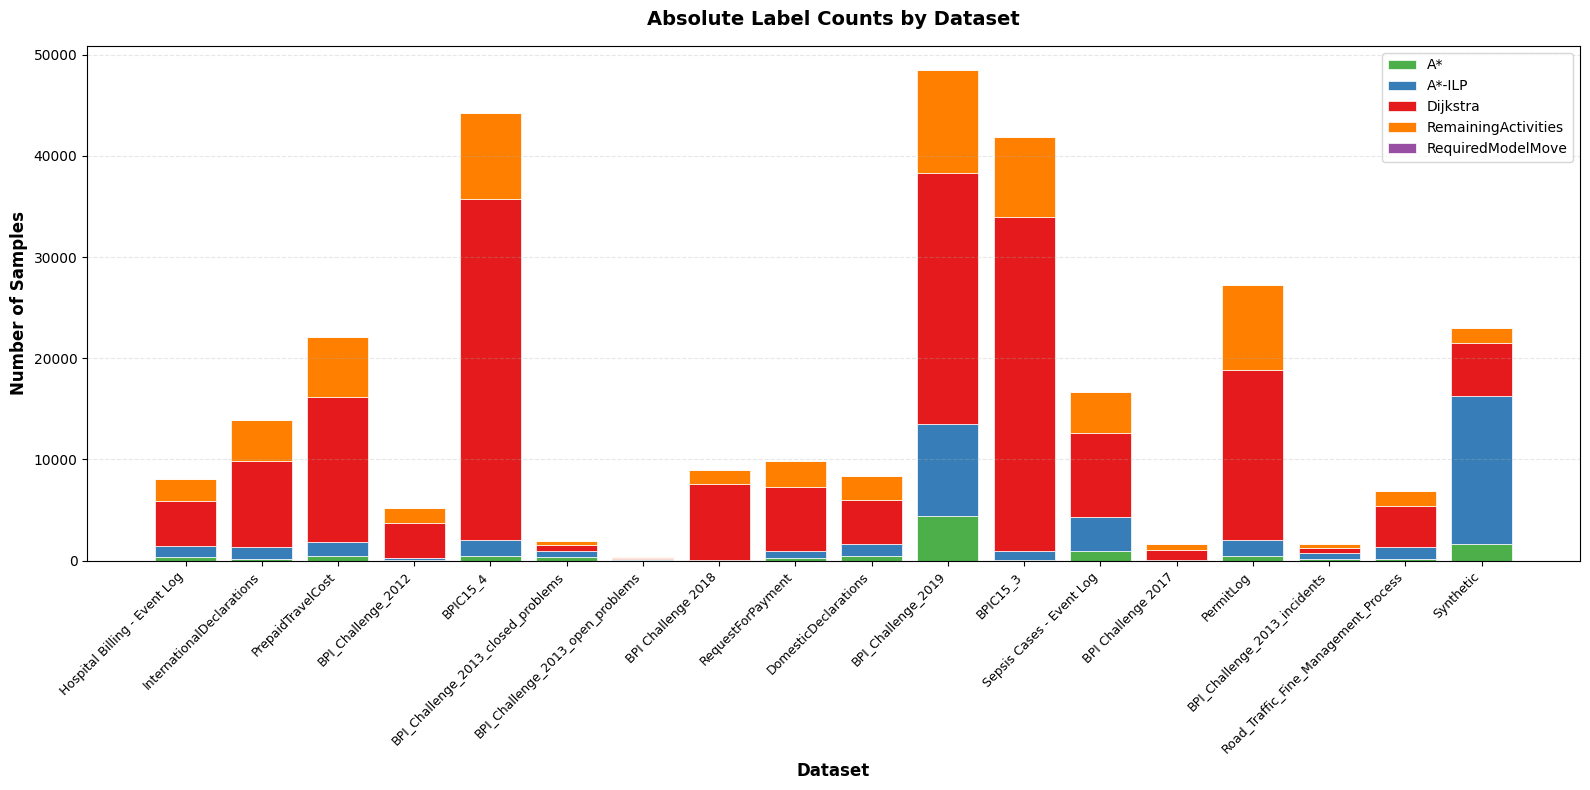


Total Label Counts Across All Datasets:
  A*: 10,306
  A*-ILP: 39,724
  Dijkstra: 176,942
  RemainingActivities: 63,366
  RequiredModelMove: 18


In [45]:
# Create stacked bar chart (absolute counts)
fig, ax = plt.subplots(figsize=(16, 8))

dataset_names = [r['name'] for r in results]
heuristics = sorted(HEURISTIC_COLORS.keys())

x = np.arange(len(dataset_names))
width = 0.8
bottom = np.zeros(len(dataset_names))

for heuristic in heuristics:
    values = [r['label_counts'].get(heuristic, 0) for r in results]
    ax.bar(x, values, width, bottom=bottom, label=heuristic,
           color=HEURISTIC_COLORS[heuristic], edgecolor='white', linewidth=0.5)
    bottom += values

ax.set_ylabel('Number of Samples', fontsize=12, fontweight='bold')
ax.set_xlabel('Dataset', fontsize=12, fontweight='bold')
ax.set_title('Absolute Label Counts by Dataset', fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(dataset_names, rotation=45, ha='right', fontsize=9)
ax.legend(loc='upper right', fontsize=10)
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

print("\nTotal Label Counts Across All Datasets:")
for h in heuristics:
    total = sum(r['label_counts'].get(h, 0) for r in results)
    print(f"  {h}: { total:,}")